# CNN1D Training for VinFast Evo 200 SoC Prediction

Train CNN1D model on Evo200 dataset to predict SoC from battery signals.

Workflow:
1. Load Evo200 CSV files (15 files) from data/raw/
2. Preprocess: normalize, create windowed dataset (60 samples/window)
3. Train CNN1D model
4. Evaluate on test set
5. Export model weights to models/soc_cnn1d.pt

## 0. Setup

## 1. Load Data

In [2]:
import sys
print(sys.executable)

d:\DoAn\SourceCode\venv\Scripts\python.exe


In [3]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing.loader import load_evo200_csv
from src.preprocessing.normalize import normalize_minmax, fit_minmax, apply_minmax
from src.preprocessing.windowing import create_cnn1d_dataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

DATA_DIR = PROJECT_ROOT / "data" / "raw"
FEATURE_COLS = ['pack_voltage_v', 'pack_current_a', 'temp_c', 'speed_kmh']
TARGET_COL = 'soc_bms'
print(f"Data directory: {DATA_DIR}")

Using device: cpu
Data directory: d:\DoAn\SourceCode\data\raw


In [4]:
evo200_files = sorted(list(Path(DATA_DIR).glob('Evo200_*.csv')))
print(f"Found {len(evo200_files)} files")

all_dfs = []
for file_path in evo200_files:
    try:
        df = load_evo200_csv(str(file_path))
        all_dfs.append(df)
        print(f"  Loaded {file_path.name}: {len(df)} rows")
    except Exception as e:
        print(f"  Error {file_path.name}: {e}")

print(f"\nTotal: {len(all_dfs)} files, {sum(len(df) for df in all_dfs)} samples")

Found 15 files
  Loaded Evo200_Mixed1.csv: 45397 rows
  Loaded Evo200_Mixed10.csv: 61576 rows
  Loaded Evo200_Mixed11.csv: 63493 rows
  Loaded Evo200_Mixed12.csv: 71457 rows
  Loaded Evo200_Mixed13.csv: 48751 rows
  Loaded Evo200_Mixed14.csv: 57793 rows
  Loaded Evo200_Mixed15.csv: 58018 rows
  Loaded Evo200_Mixed2.csv: 74341 rows
  Loaded Evo200_Mixed3.csv: 79762 rows
  Loaded Evo200_Mixed4.csv: 23579 rows
  Loaded Evo200_Mixed5.csv: 36344 rows
  Loaded Evo200_Mixed6.csv: 63163 rows
  Loaded Evo200_Mixed7.csv: 77922 rows
  Loaded Evo200_Mixed8.csv: 70674 rows
  Loaded Evo200_Mixed9.csv: 67681 rows

Total: 15 files, 899951 samples


## 2. Normalize Data

In [5]:
df_combined = pd.concat(all_dfs, ignore_index=True)
features = df_combined[FEATURE_COLS].copy()
targets = df_combined[TARGET_COL].copy()

norm_params   = fit_minmax(features)
features_norm = apply_minmax(features, norm_params)

df_norm = features_norm.copy()
# SoC vốn 0-100 → normalize về [0,1] để metric nhất quán với features
df_norm[TARGET_COL] = targets.values / 100.0

print(f"Data shape: {df_norm.shape}")
print(f"Features + label (normalized):")
for col in FEATURE_COLS + [TARGET_COL]:
    print(f"  {col}: [{df_norm[col].min():.3f}, {df_norm[col].max():.3f}]")
print(f"\nnorm_params:")
for col, v in norm_params.items():
    print(f"  {col}: min={v['min']:.4f}  max={v['max']:.4f}")

Data shape: (899951, 5)
Features + label (normalized):
  pack_voltage_v: [0.000, 1.000]
  pack_current_a: [0.000, 1.000]
  temp_c: [0.000, 1.000]
  speed_kmh: [0.000, 1.000]
  soc_bms: [0.000, 1.000]

norm_params:
  pack_voltage_v: min=69.8820  max=73.8180
  pack_current_a: min=-2.2600  max=21.2200
  temp_c: min=0.0000  max=46.0000
  speed_kmh: min=0.0000  max=54.1000


## 3. Create Windows

In [6]:
WINDOW_SIZE = 60
STEP = 10

X, y = create_cnn1d_dataset(df_norm, window_size=WINDOW_SIZE, step=STEP)

n_train = int(0.8 * len(X))
X_train, X_test = X[:n_train], X[n_train:]
y_train, y_test = y[:n_train], y[n_train:]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

X shape: (89990, 60, 4)
y shape: (89990,)
Train: 71992, Test: 17998


In [7]:
# Preview dữ liệu đã normalize trước khi tạo DataLoader
print("=== Sample của df_norm (10 dòng đầu) ===")
display(df_norm.head(10))
print(f"\nShape: {df_norm.shape}")
print(f"Columns: {list(df_norm.columns)}")

=== Sample của df_norm (10 dòng đầu) ===


,pack_voltage_v,pack_current_a,temp_c,speed_kmh,soc_bms
0,0.933943,0.09753,0.847826,0.0,1.0
1,0.934959,0.09753,0.847826,0.0,1.0
2,0.934959,0.09753,0.847826,0.0,1.0
3,0.935976,0.09753,0.847826,0.0,1.0
4,0.935976,0.09753,0.847826,0.0,1.0
5,0.934959,0.09753,0.847826,0.0,1.0
6,0.934451,0.09753,0.847826,0.0,1.0
7,0.934451,0.09753,0.847826,0.0,1.0
8,0.934959,0.09753,0.847826,0.0,1.0
9,0.934959,0.09753,0.847826,0.0,1.0



Shape: (899951, 5)
Columns: ['pack_voltage_v', 'pack_current_a', 'temp_c', 'speed_kmh', 'soc_bms']


## 4. DataLoaders

In [8]:
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Train batches: 1125, Test batches: 282


## 5. Model

In [9]:
class CNN1D(nn.Module):
    def __init__(self, in_channels=4):
        super(CNN1D, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.pool(x).squeeze(-1)
        return self.fc(x)

model = CNN1D(len(FEATURE_COLS)).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 34,241


## 6. Train

In [10]:
import copy

criterion = nn.HuberLoss(delta=1.0)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=8, min_lr=1e-6)


def train_epoch():
    model.train()
    loss_sum = 0.0
    all_preds, all_targets = [], []
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(X).squeeze(1)
        loss = criterion(pred, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        loss_sum += loss.item() * X.size(0)
        all_preds.append(pred.detach().cpu().numpy())
        all_targets.append(y.cpu().numpy())
    all_preds   = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    train_mae  = np.mean(np.abs(all_preds - all_targets))
    train_rmse = np.sqrt(np.mean((all_preds - all_targets) ** 2))
    return loss_sum / len(train_dataset), train_mae, train_rmse


def eval_epoch():
    model.eval()
    loss_sum, preds, targets = 0.0, [], []
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            pred = model(X).squeeze(1)
            loss = criterion(pred, y)
            loss_sum += loss.item() * X.size(0)
            preds.append(pred.cpu().numpy())
            targets.append(y.cpu().numpy())
    preds   = np.concatenate(preds)
    targets = np.concatenate(targets)
    mae  = np.mean(np.abs(preds - targets))
    rmse = np.sqrt(np.mean((preds - targets) ** 2))
    return loss_sum / len(test_dataset), mae, rmse, preds, targets


best_mae     = float('inf')
best_epoch   = 0
best_state   = None
patience_cnt = 0
history = {'train_loss': [], 'val_loss': [],
           'train_mae': [], 'train_rmse': [],
           'mae': [], 'rmse': []}

for epoch in range(1, 51):
    train_loss, train_mae, train_rmse = train_epoch()
    val_loss, mae, rmse, _, _ = eval_epoch()
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_mae'].append(train_mae)
    history['train_rmse'].append(train_rmse)
    history['mae'].append(mae)
    history['rmse'].append(rmse)

    if mae < best_mae:
        best_mae     = mae
        best_epoch   = epoch
        best_state   = copy.deepcopy(model.state_dict())
        patience_cnt = 0
    else:
        patience_cnt += 1

    lr = optimizer.param_groups[0]['lr']
    print(f"[{epoch:2d}] train={train_loss:.5f}  val={val_loss:.5f}  "
          f"train_mae={train_mae:.4f}  val_mae={mae:.4f}  lr={lr:.1e}")

    if patience_cnt >= 5:
        print(f"Early stop at epoch {epoch}")
        break

model.load_state_dict(best_state)
print(f"\nRestored best model — epoch {best_epoch}  MAE={best_mae:.4f}  ({best_mae*100:.2f}%)")

[ 1] train=0.01893  val=0.00313  train_mae=0.1297  val_mae=0.0603  lr=1.0e-04


KeyboardInterrupt: 

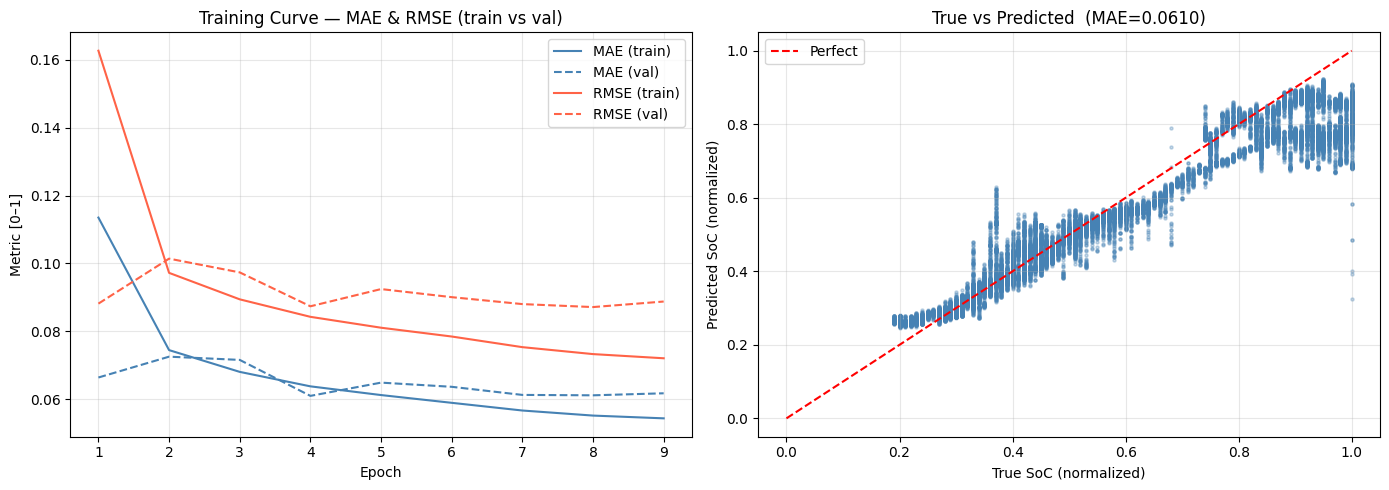

Best MAE:  0.0610  (6.10%)
Best RMSE: 0.0874  (8.74%)


In [ ]:
# Vẽ đồ thị sau train — metric curve + true vs predicted scatter
_, _, _, y_pred_plot, y_true_plot = eval_epoch()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training curve — train + val MAE/RMSE overlay
ax1 = axes[0]
epochs_range = range(1, len(history['mae']) + 1)
ax1.plot(epochs_range, history['train_mae'],  label='MAE (train)',  color='steelblue')
ax1.plot(epochs_range, history['mae'],        label='MAE (val)',    color='steelblue', linestyle='--')
ax1.plot(epochs_range, history['train_rmse'], label='RMSE (train)', color='tomato')
ax1.plot(epochs_range, history['rmse'],       label='RMSE (val)',   color='tomato',    linestyle='--')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Metric [0–1]')
ax1.set_title('Training Curve — MAE & RMSE (train vs val)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: True vs Predicted scatter
ax2 = axes[1]
ax2.scatter(y_true_plot, y_pred_plot, alpha=0.3, s=5, color='steelblue')
ax2.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Perfect')
ax2.set_xlabel('True SoC (normalized)')
ax2.set_ylabel('Predicted SoC (normalized)')
ax2.set_title(f'True vs Predicted  (MAE={best_mae:.4f})')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_rmse = history['rmse'][history['mae'].index(min(history['mae']))]
print(f"Best MAE:  {best_mae:.4f}  ({best_mae*100:.2f}%)")
print(f"Best RMSE: {best_rmse:.4f}  ({best_rmse*100:.2f}%)")

## 7. Save

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

torch.save({
    'model_state': model.state_dict(),
    'history':     history,
    'best_mae':    best_mae,
    'best_epoch':  best_epoch,
    'feature_cols': FEATURE_COLS,
    'target_col':   TARGET_COL,
    'window_size':  WINDOW_SIZE,
    'label_scale':  100.0,  # label đã /100 khi train → inference cần ×100 để ra %
}, str(MODEL_DIR / 'soc_cnn1d.pt'))

print(f"Saved to {MODEL_DIR / 'soc_cnn1d.pt'}")
print(f"  best_epoch={best_epoch}  best_mae={best_mae:.4f}  ({best_mae*100:.2f}%)")

In [ ]:
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

torch.save({
    'model_state':  model.state_dict(),
    'history':      history,
    'best_mae':     best_mae,
    'best_epoch':   best_epoch,
    'feature_cols': FEATURE_COLS,
    'target_col':   TARGET_COL,
    'window_size':  WINDOW_SIZE,
    'label_scale':  100.0,       # label đã /100 khi train → inference cần ×100 để ra %
    'feature_norm': norm_params, # min/max thật từ training data → dùng cho runtime normalize
}, str(MODEL_DIR / 'soc_cnn1d.pt'))

print(f"Saved to {MODEL_DIR / 'soc_cnn1d.pt'}")
print(f"  best_epoch={best_epoch}  best_mae={best_mae:.4f}  ({best_mae*100:.2f}%)")
print(f"  label_scale=100.0  feature_norm keys: {list(norm_params.keys())}")

Saved to D:\DoAn\SourceCode\models\soc_cnn1d.pt
  best_epoch=4  best_mae=0.0610  (6.10%)
  label_scale=100.0  feature_norm keys: ['pack_voltage_v', 'pack_current_a', 'temp_c', 'speed_kmh']


ModuleNotFoundError: No module named 'src'